# Data Generation using Monte Carlo Simulation (GBM) for Machine Learning

**Assignment**: Data Generation using Modelling and Simulation for Machine Learning  
**Simulator**: Geometric Brownian Motion (GBM) — Industry-standard stochastic financial model  
**Goal**: Simulate 1000 stock price paths → Extract features → Train & compare ML models


In [1]:

!pip install numpy pandas scikit-learn matplotlib seaborn xgboost lightgbm -q


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

np.random.seed(42)
print('All libraries loaded successfully!')


All libraries loaded successfully!


In [14]:
# Parameter Bounds
PARAM_BOUNDS = {
    'S0':    {'low': 50.0,   'high': 500.0,  'desc': 'Initial Stock Price (USD)'},
    'mu':    {'low': -0.10,  'high': 0.40,   'desc': 'Annual Drift (return)'},
    'sigma': {'low': 0.05,   'high': 0.60,   'desc': 'Annual Volatility'},
    'T':     {'low': 0.25,   'high': 2.0,    'desc': 'Time Horizon (years)'},
    'N':     {'low': 30,     'high': 252,    'desc': 'Number of Time Steps'},
}

print('Parameter Bounds Summary:')
print('-' * 60)
for k, v in PARAM_BOUNDS.items():
    print(f"  {k:6s} | [{v['low']:6.2f}, {v['high']:6.2f}] | {v['desc']}")


Parameter Bounds Summary:
------------------------------------------------------------
  S0     | [ 50.00, 500.00] | Initial Stock Price (USD)
  mu     | [ -0.10,   0.40] | Annual Drift (return)
  sigma  | [  0.05,   0.60] | Annual Volatility
  T      | [  0.25,   2.00] | Time Horizon (years)
  N      | [ 30.00, 252.00] | Number of Time Steps


## Step 4 & 5: GBM Simulator + Generate 1000 Simulations


In [15]:
def gbm_simulator(S0, mu, sigma, T, N):
    """
    Geometric Brownian Motion simulator.
    Returns final stock price and path statistics.

    dS = mu*S*dt + sigma*S*dW
    Exact solution: S_t = S0 * exp((mu - sigma²/2)*t + sigma*W_t)
    """
    dt = T / N
    # Generate random Wiener increments
    dW = np.random.normal(0, np.sqrt(dt), N)
    # Incremental log returns
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * dW
    # Cumulative price path
    price_path = S0 * np.exp(np.cumsum(log_returns))
    price_path = np.concatenate([[S0], price_path])

    # Extract features from the path
    final_price = price_path[-1]
    total_return = (final_price - S0) / S0
    max_price = np.max(price_path)
    min_price = np.min(price_path)
    max_drawdown = (max_price - min_price) / max_price
    path_volatility = np.std(np.diff(price_path) / price_path[:-1]) * np.sqrt(252)

    return {
        'final_price': final_price,
        'total_return': total_return,
        'max_price': max_price,
        'min_price': min_price,
        'max_drawdown': max_drawdown,
        'path_volatility': path_volatility,
        'price_range': max_price - min_price,
    }

# ── Generate 1000 simulations ──────────────────────────────────
N_SIMULATIONS = 1000
records = []

for i in range(N_SIMULATIONS):
    # Random parameter sampling (Latin Hypercube style via uniform)
    S0    = np.random.uniform(PARAM_BOUNDS['S0']['low'],    PARAM_BOUNDS['S0']['high'])
    mu    = np.random.uniform(PARAM_BOUNDS['mu']['low'],    PARAM_BOUNDS['mu']['high'])
    sigma = np.random.uniform(PARAM_BOUNDS['sigma']['low'], PARAM_BOUNDS['sigma']['high'])
    T     = np.random.uniform(PARAM_BOUNDS['T']['low'],     PARAM_BOUNDS['T']['high'])
    N     = int(np.random.uniform(PARAM_BOUNDS['N']['low'], PARAM_BOUNDS['N']['high']))

    # Run simulator
    result = gbm_simulator(S0, mu, sigma, T, N)

    records.append({
        # Input parameters
        'S0': S0, 'mu': mu, 'sigma': sigma, 'T': T, 'N': N,
        # Derived features
        'sharpe_approx': mu / sigma,
        'risk_reward': mu / (sigma**2),
        # Simulation outputs
        **result
    })

df = pd.DataFrame(records)
print(f'Generated {N_SIMULATIONS} simulations')
print(f'Dataset shape: {df.shape}')
print('\nFirst 5 rows:')
df.head()


Generated 1000 simulations
Dataset shape: (1000, 14)

First 5 rows:


,S0,mu,sigma,T,N,sharpe_approx,risk_reward,final_price,total_return,max_price,min_price,max_drawdown,path_volatility,price_range
0,218.543053,0.375357,0.452597,1.297652,64,0.829341,1.832407,270.017257,0.235533,270.017257,138.865970,0.485714,1.051903,131.151287
1,272.208018,0.161366,0.285148,0.294483,53,0.565905,1.984604,279.087825,0.025274,287.288484,245.741162,0.144619,0.311838,41.547321
2,354.903963,-0.091706,0.331651,0.646368,173,-0.276514,-0.833748,578.634310,0.630397,608.739200,338.948771,0.443195,0.315850,269.790429
3,456.148808,0.152626,0.504552,0.810087,228,0.302499,0.599540,312.087924,-0.315820,660.695910,312.087924,0.527638,0.473658,348.607986
4,206.990720,0.364765,0.506841,1.938797,57,0.719683,1.419939,489.108757,1.362950,598.073532,206.990720,0.653904,1.319036,391.082812


In [16]:
# Dataset statistics
print('Dataset Statistical Summary:')
df.describe().round(4)


Dataset Statistical Summary:


,S0,mu,sigma,T,N,sharpe_approx,risk_reward,final_price,total_return,max_price,min_price,max_drawdown,path_volatility,price_range
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,274.7094,0.1460,0.3258,1.1263,137.1660,0.6675,4.7616,326.8468,0.1887,394.9461,226.5549,0.3870,0.4992,168.3912
std,130.3953,0.1473,0.1594,0.5091,63.5454,0.9698,12.2229,222.0053,0.5159,246.1241,119.0424,0.1714,0.3263,171.3664
min,50.2583,-0.0999,0.0501,0.2533,30.0000,-1.4394,-26.8114,17.4975,-0.8076,51.5846,16.6314,0.0408,0.0322,2.3205
25%,165.0485,0.0188,0.1864,0.6708,84.0000,0.0569,0.1294,163.0314,-0.1120,213.6750,125.8203,0.2553,0.2505,62.4486
50%,276.2623,0.1494,0.3213,1.1380,133.0000,0.4674,1.1610,289.9728,0.0938,367.2729,214.3482,0.3815,0.4246,122.1318
75%,384.3983,0.2714,0.4663,1.5644,192.0000,0.9286,3.7137,437.6907,0.3990,517.4957,316.6839,0.5143,0.6747,222.2439
max,499.6053,0.3999,0.5982,1.9972,251.0000,6.3877,110.5800,1609.2488,4.2875,2191.3659,499.3227,0.8485,2.1267,1802.7047


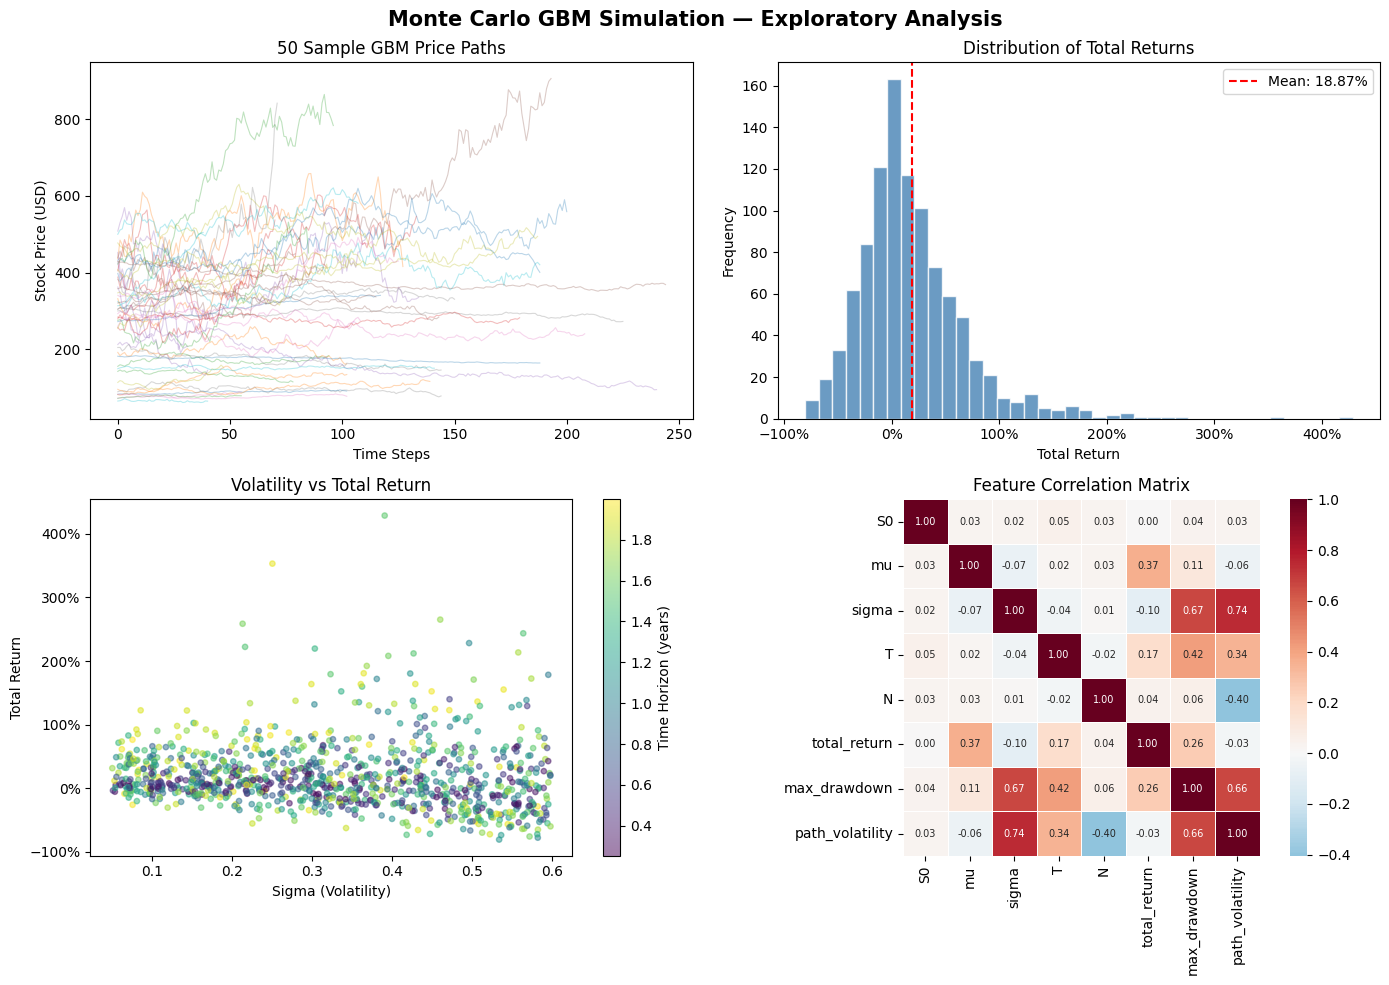

Visualization saved.


In [17]:
# ── Visualize simulation paths ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Monte Carlo GBM Simulation — Exploratory Analysis', fontsize=15, fontweight='bold')

# 1. Sample price paths
ax = axes[0, 0]
np.random.seed(42)
for _ in range(50):
    idx = np.random.randint(0, N_SIMULATIONS)
    row = df.iloc[idx]
    path = row['S0'] * np.exp(np.cumsum(
        (row['mu'] - 0.5*row['sigma']**2) * (row['T']/row['N']) +
        row['sigma'] * np.sqrt(row['T']/row['N']) * np.random.normal(size=int(row['N']))
    ))
    ax.plot(path, alpha=0.3, linewidth=0.8)
ax.set_title('50 Sample GBM Price Paths')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Stock Price (USD)')

# 2. Distribution of total returns
ax = axes[0, 1]
ax.hist(df['total_return'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df['total_return'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_return'].mean():.2%}")
ax.set_title('Distribution of Total Returns')
ax.set_xlabel('Total Return'); ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

# 3. Volatility vs Return scatter
ax = axes[1, 0]
sc = ax.scatter(df['sigma'], df['total_return'], c=df['T'], cmap='viridis', alpha=0.5, s=15)
plt.colorbar(sc, ax=ax, label='Time Horizon (years)')
ax.set_title('Volatility vs Total Return')
ax.set_xlabel('Sigma (Volatility)'); ax.set_ylabel('Total Return')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 4. Correlation heatmap
ax = axes[1, 1]
cols = ['S0','mu','sigma','T','N','total_return','max_drawdown','path_volatility']
corr = df[cols].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=True, linewidths=0.5, annot_kws={'size':7})
ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('simulation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved.')


## Step 6: Train & Compare 10 ML Models

**Target variable**: `total_return` — predicting the total return of a stock path given simulation parameters.


In [7]:
# ── Feature Engineering & Train/Test Split ──────────────────────
FEATURES = ['S0', 'mu', 'sigma', 'T', 'N', 'sharpe_approx', 'risk_reward']
TARGET   = 'total_return'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Features: {FEATURES}')
print(f'Target  : {TARGET}')


Train size: 800 | Test size: 200
Features: ['S0', 'mu', 'sigma', 'T', 'N', 'sharpe_approx', 'risk_reward']
Target  : total_return


In [18]:
import time

MODELS = {
    'Linear Regression':       (LinearRegression(),                    True),
    'Ridge Regression':        (Ridge(alpha=1.0),                      True),
    'Lasso Regression':        (Lasso(alpha=0.001),                    True),
    'K-Nearest Neighbors':     (KNeighborsRegressor(n_neighbors=7),    True),
    'Support Vector Regr.':    (SVR(kernel='rbf', C=10),               True),
    'Decision Tree':           (DecisionTreeRegressor(max_depth=8),    False),
    'Random Forest':           (RandomForestRegressor(n_estimators=100, random_state=42), False),
    'Extra Trees':             (ExtraTreesRegressor(n_estimators=100, random_state=42),   False),
    'Gradient Boosting':       (GradientBoostingRegressor(n_estimators=100, random_state=42), False),
    'XGBoost':                 (XGBRegressor(n_estimators=100, random_state=42, verbosity=0), False),
    'LightGBM':                (LGBMRegressor(n_estimators=100, random_state=42, verbose=-1), False),
}

results = []

for name, (model, use_scaled) in MODELS.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Cross-val R2
    cv_r2 = cross_val_score(model, Xtr, y_train, cv=5, scoring='r2').mean()

    results.append({
        'Model': name,
        'RMSE': round(rmse, 5),
        'MAE':  round(mae,  5),
        'R² (Test)': round(r2,    4),
        'R² (CV-5)': round(cv_r2, 4),
        'Train Time (s)': round(train_time, 3)
    })
    print(f'{name:28s} | RMSE={rmse:.5f} | MAE={mae:.5f} | R²={r2:.4f} | CV-R²={cv_r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R² (Test)', ascending=False).reset_index(drop=True)
results_df.index += 1  # 1-indexed rank
print('\nAll models trained and evaluated.')


Linear Regression            | RMSE=0.42020 | MAE=0.29620 | R²=0.2425 | CV-R²=0.1361
Ridge Regression             | RMSE=0.42022 | MAE=0.29621 | R²=0.2424 | CV-R²=0.1363
Lasso Regression             | RMSE=0.42035 | MAE=0.29638 | R²=0.2420 | CV-R²=0.1367
K-Nearest Neighbors          | RMSE=0.46060 | MAE=0.31805 | R²=0.0898 | CV-R²=0.0541
Support Vector Regr.         | RMSE=0.44078 | MAE=0.30165 | R²=0.1665 | CV-R²=0.0180
Decision Tree                | RMSE=0.55430 | MAE=0.37761 | R²=-0.3182 | CV-R²=-0.3142
Random Forest                | RMSE=0.46544 | MAE=0.33136 | R²=0.0706 | CV-R²=0.0808
Extra Trees                  | RMSE=0.45489 | MAE=0.30868 | R²=0.1123 | CV-R²=0.0674
Gradient Boosting            | RMSE=0.47583 | MAE=0.34080 | R²=0.0287 | CV-R²=0.0967
XGBoost                      | RMSE=0.50950 | MAE=0.35652 | R²=-0.1137 | CV-R²=-0.0772
LightGBM                     | RMSE=0.46817 | MAE=0.33912 | R²=0.0597 | CV-R²=-0.0104

All models trained and evaluated.


In [19]:
print('='*75)
print('        MODEL COMPARISON TABLE — Sorted by R² (Test)')
print('='*75)
print(results_df.to_string())
print('='*75)

best = results_df.iloc[0]
print(f"\n BEST MODEL: {best['Model']}")
print(f"   R² (Test)  = {best['R² (Test)']}")
print(f"   RMSE       = {best['RMSE']}")
print(f"   MAE        = {best['MAE']}")


        MODEL COMPARISON TABLE — Sorted by R² (Test)
                   Model     RMSE      MAE  R² (Test)  R² (CV-5)  Train Time (s)
1      Linear Regression  0.42020  0.29620     0.2425     0.1361           0.005
2       Ridge Regression  0.42022  0.29621     0.2424     0.1363           0.002
3       Lasso Regression  0.42035  0.29638     0.2420     0.1367           0.006
4   Support Vector Regr.  0.44078  0.30165     0.1665     0.0180           0.249
5            Extra Trees  0.45489  0.30868     0.1123     0.0674           0.936
6    K-Nearest Neighbors  0.46060  0.31805     0.0898     0.0541           0.001
7          Random Forest  0.46544  0.33136     0.0706     0.0808           1.329
8               LightGBM  0.46817  0.33912     0.0597    -0.0104           0.070
9      Gradient Boosting  0.47583  0.34080     0.0287     0.0967           0.348
10               XGBoost  0.50950  0.35652    -0.1137    -0.0772           0.177
11         Decision Tree  0.55430  0.37761    -0.3182   

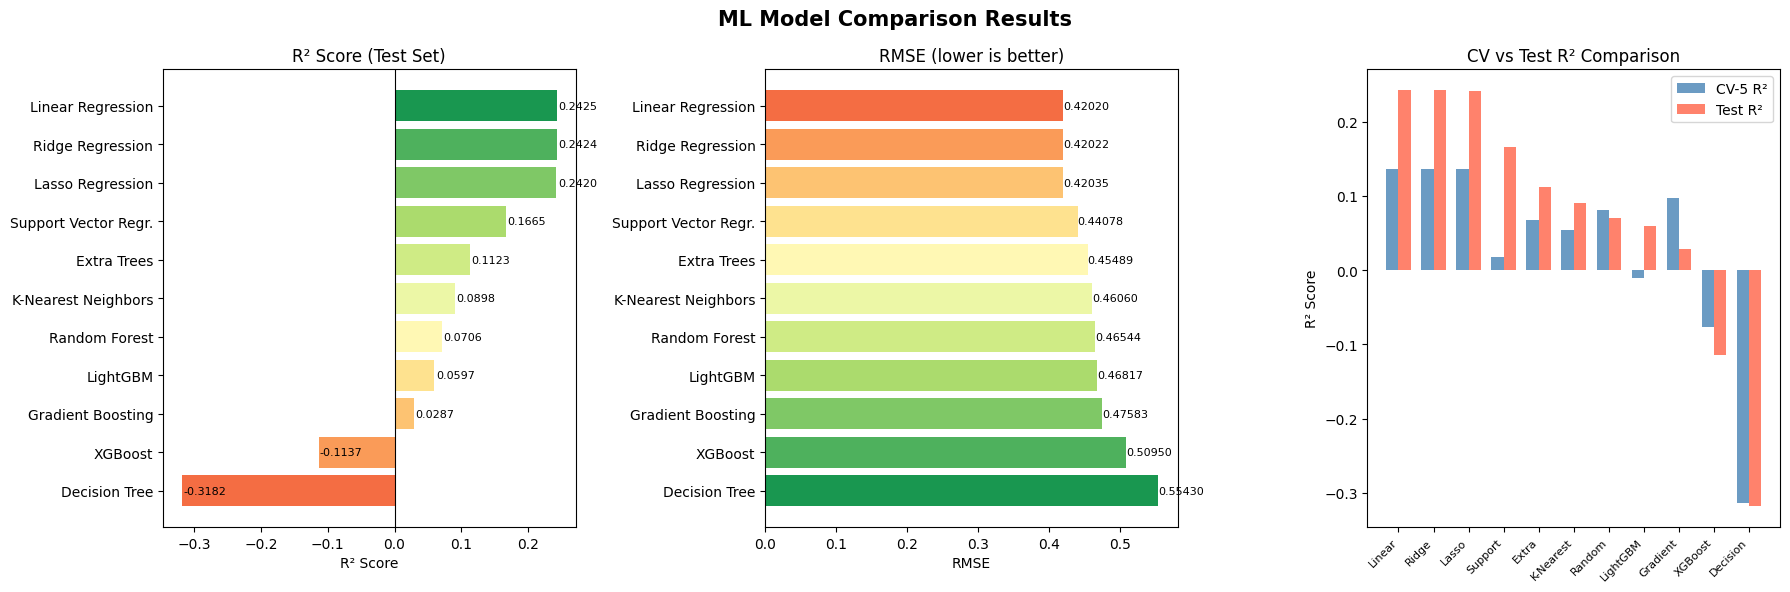

Model comparison chart saved.


In [20]:
# ── Result Graphs ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ML Model Comparison Results', fontsize=15, fontweight='bold')

models_sorted = results_df['Model']
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))

# R² comparison
ax = axes[0]
bars = ax.barh(models_sorted[::-1], results_df['R² (Test)'][::-1], color=colors)
ax.set_xlabel('R² Score'); ax.set_title('R² Score (Test Set)')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, results_df['R² (Test)'][::-1]):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

# RMSE comparison
ax = axes[1]
bars = ax.barh(models_sorted[::-1], results_df['RMSE'][::-1], color=colors[::-1])
ax.set_xlabel('RMSE'); ax.set_title('RMSE (lower is better)')
for bar, val in zip(bars, results_df['RMSE'][::-1]):
    ax.text(bar.get_width()+0.0001, bar.get_y()+bar.get_height()/2, f'{val:.5f}', va='center', fontsize=8)

# CV R² vs Test R²
ax = axes[2]
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w/2, results_df['R² (CV-5)'], w, label='CV-5 R²', color='steelblue', alpha=0.8)
ax.bar(x + w/2, results_df['R² (Test)'],  w, label='Test R²',  color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([m.split()[0] for m in results_df['Model']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R² Score'); ax.set_title('CV vs Test R² Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model comparison chart saved.')


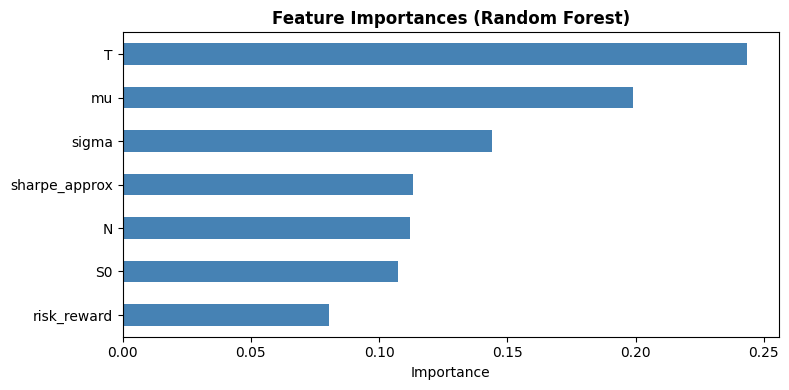

Feature importance chart saved.


In [21]:
# ── Feature Importance from Best Tree Model ──────────────────────
rf_model = [m for name, (m, _) in MODELS.items() if name == 'Random Forest'][0]

importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved.')


In [22]:
# Save dataset to CSV
df.to_csv('gbm_simulation_dataset.csv', index=False)
results_df.to_csv('model_comparison_results.csv', index=True)
print('Datasets saved: gbm_simulation_dataset.csv & model_comparison_results.csv')
print('\nFinal Summary:')
print(f'   Simulator    : Geometric Brownian Motion (GBM)')
print(f'   Simulations  : {N_SIMULATIONS}')
print(f'   Features     : {FEATURES}')
print(f'   Target       : {TARGET}')
print(f'   Best Model   : {results_df.iloc[0]["Model"]} (R²={results_df.iloc[0]["R² (Test)"]})')


Datasets saved: gbm_simulation_dataset.csv & model_comparison_results.csv

Final Summary:
   Simulator    : Geometric Brownian Motion (GBM)
   Simulations  : 1000
   Features     : ['S0', 'mu', 'sigma', 'T', 'N', 'sharpe_approx', 'risk_reward']
   Target       : total_return
   Best Model   : Linear Regression (R²=0.2425)
